# Diffusion spatiale du déplacement forcé, Colombie 2000-2022

Ce carnet lit les tableaux et les figures que `run_all.py` écrit dans
`outputs/`. Ni le panel ni les modèles n'y sont recalculés.

Pour régénérer les sorties : `python run_all.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

import style
from config import ANNEES_LISA, K_VOISINS

style.appliquer()
TABLEAUX = RACINE / "outputs" / "tables"
FIGURES = RACINE / "outputs" / "figures"
TRAITE = RACINE / "data" / "processed"
pd.set_option("display.width", 180)

## 1. Le nettoyage du registre

L'étape 1 écrit un journal de nettoyage : une ligne par règle appliquée, avec le
nombre d'enregistrements et de victimes écartés.

In [2]:
journal = pd.read_csv(TABLEAUX / "01_journal_nettoyage.csv")
journal.style.format({"lignes_ecartees": "{:,.0f}", "victimes_ecartees": "{:,.0f}"})

,motif,lignes_ecartees,victimes_ecartees
0,Hors de la fenêtre retenue ou année aberrante,"187,268","2,365,805"
1,Municipalité non renseignée,"2,164","46,936"
2,Code DIVIPOLA non conforme,49,175


In [3]:
panel = pd.read_parquet(TRAITE / "panel.parquet")
print(f"{panel['divipola'].nunique()} municipalités x {panel['annee'].nunique()} années "
      f"= {len(panel):,} observations")
print(f"part de municipalité-années sans aucun déplacement : "
      f"{(panel['deplacement'] == 0).mean():.1%}")

1121 municipalités x 23 années = 25,783 observations
part de municipalité-années sans aucun déplacement : 16.3%


Dans ce registre, une municipalité-année absente veut dire zéro victime
enregistrée et non une valeur manquante. La grille est donc complétée par des
zéros. Les laisser vides supprimerait une observation sur six et gonflerait les
moyennes.

## 2. Volume et structure spatiale

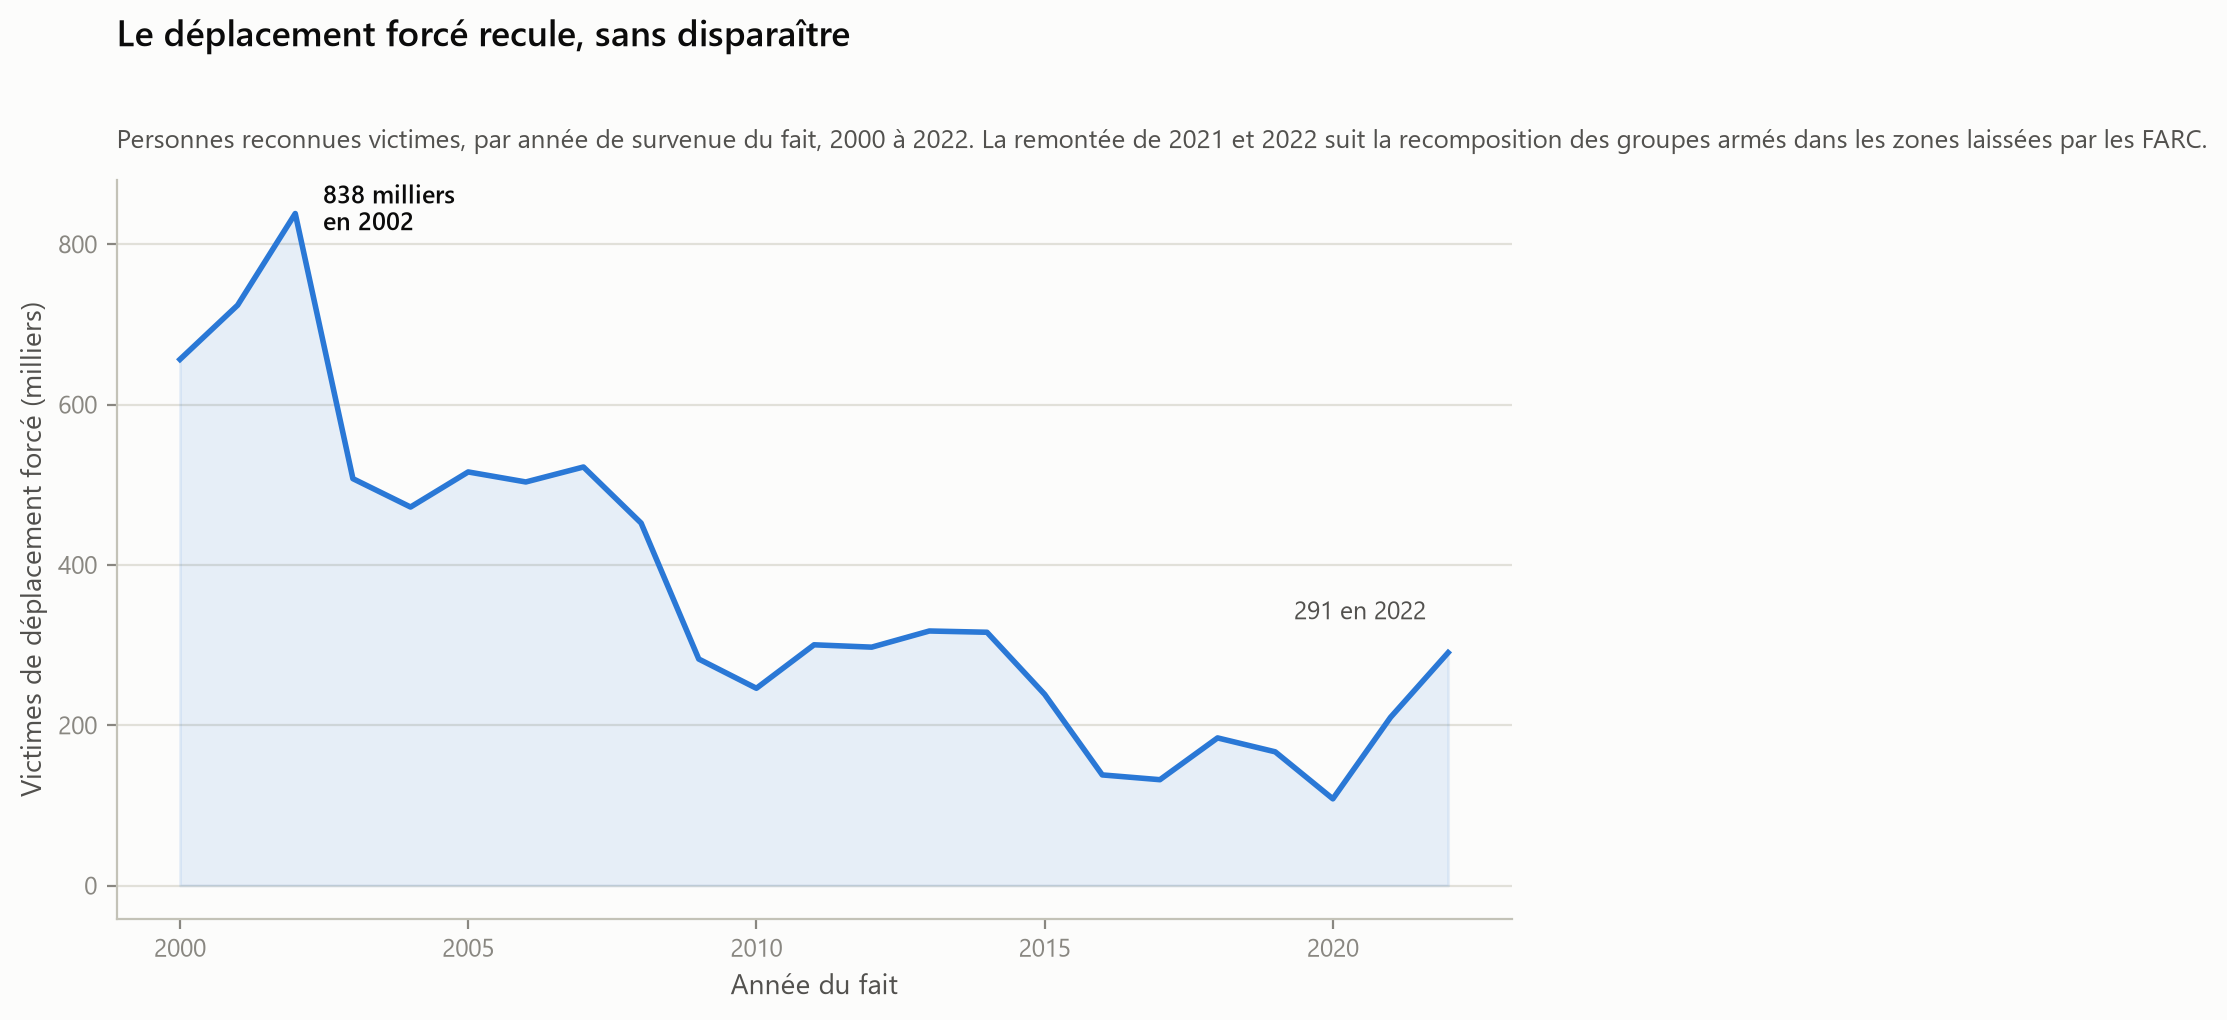

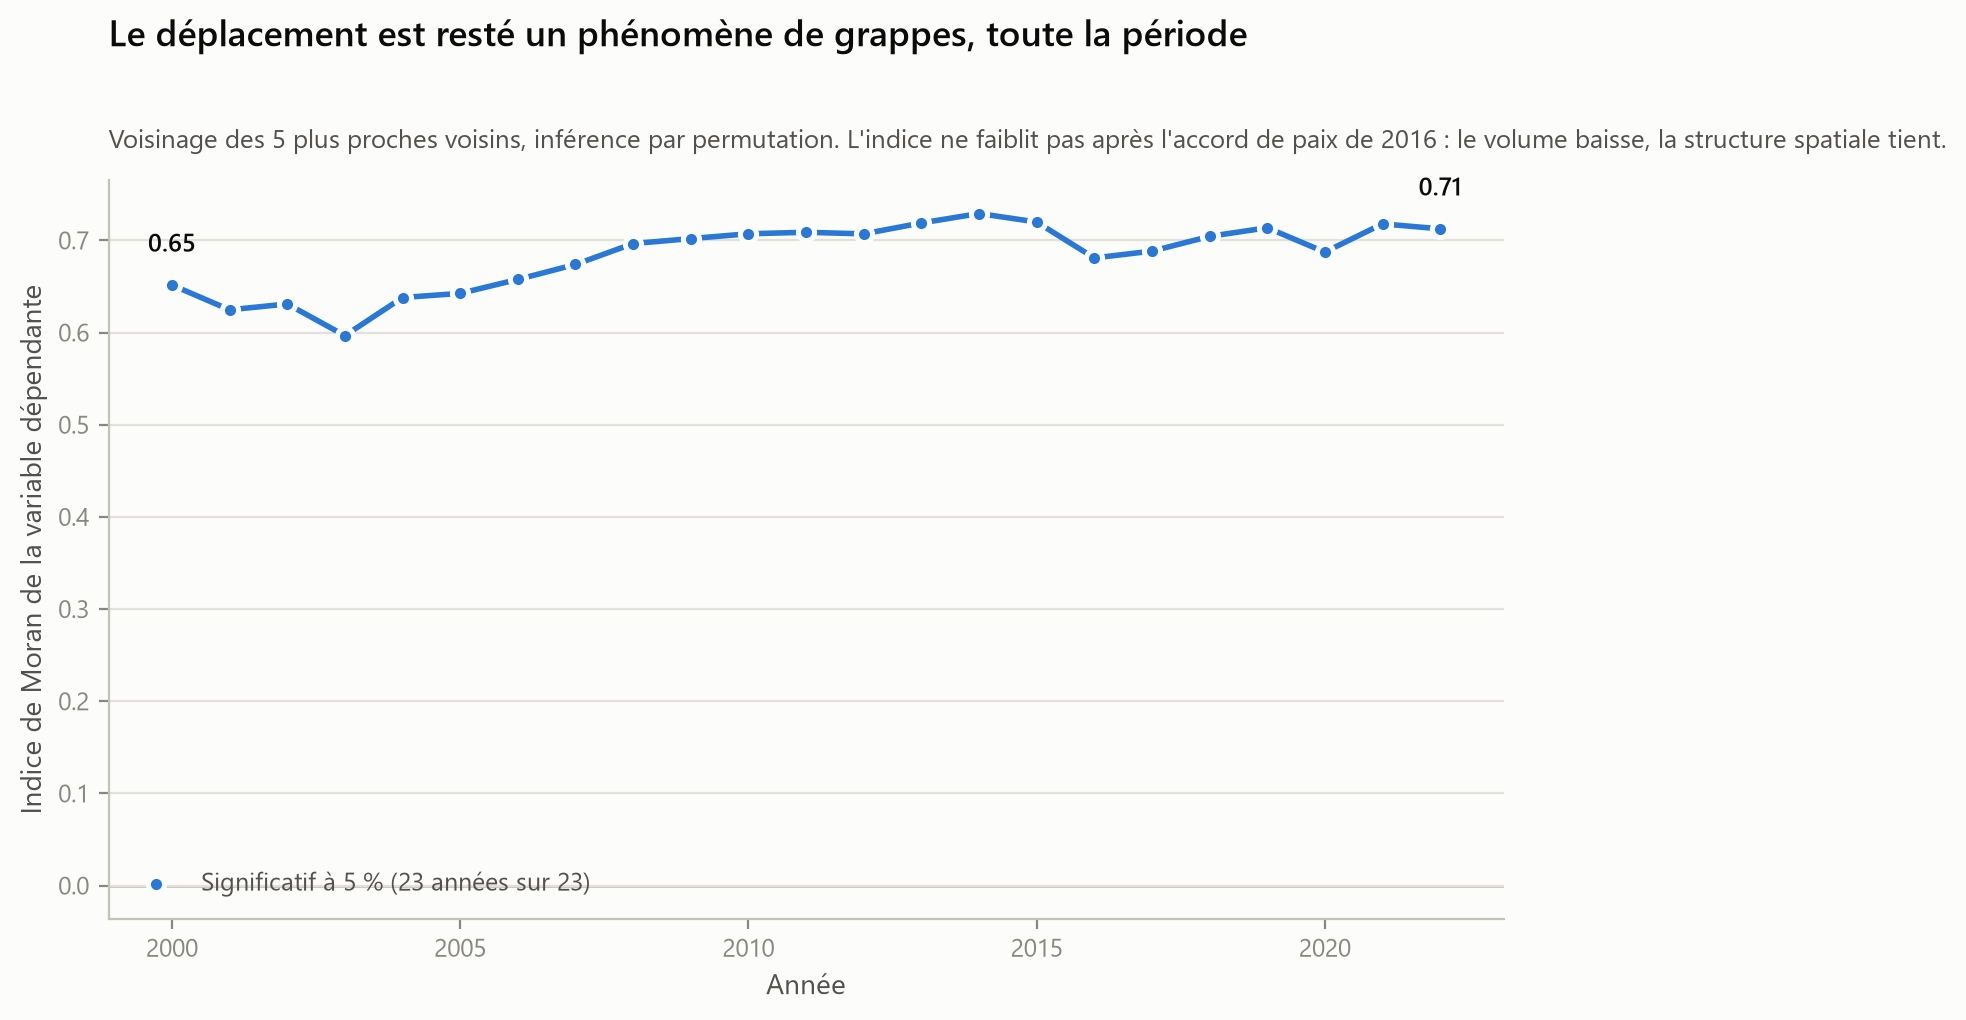

In [4]:
display(Image(filename=str(FIGURES / "fig01_serie_nationale.png")))
display(Image(filename=str(FIGURES / "fig02_moran_global.png")))

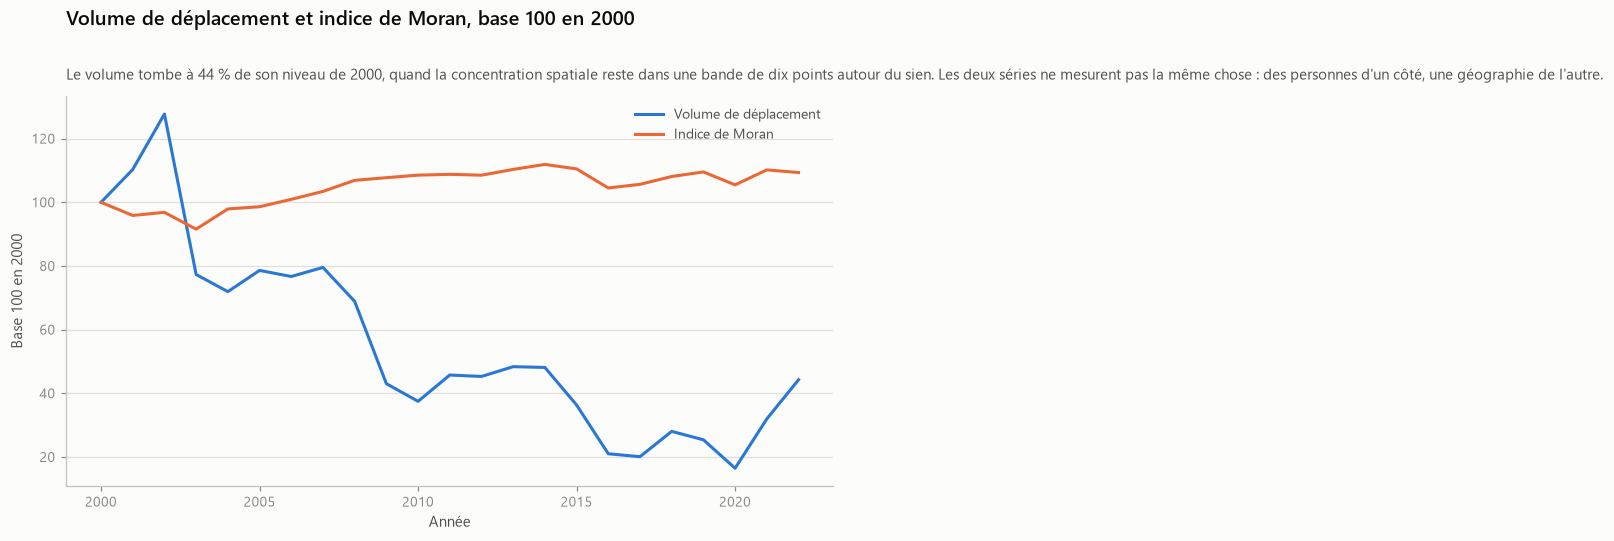

In [5]:
moran = pd.read_csv(TABLEAUX / "02_moran_global.csv")
national = pd.read_csv(TABLEAUX / "01_serie_nationale.csv")

compare = national[["annee", "deplacement"]].merge(moran[["annee", "moran_I"]], on="annee")
compare["indice_volume"] = compare["deplacement"] / compare["deplacement"].iloc[0] * 100
compare["indice_moran"] = compare["moran_I"] / compare["moran_I"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.grid(axis="y", zorder=0)
ax.plot(compare["annee"], compare["indice_volume"], color=style.SERIE_1, lw=2,
        label="Volume de déplacement", zorder=3)
ax.plot(compare["annee"], compare["indice_moran"], color=style.SERIE_2, lw=2,
        label="Indice de Moran", zorder=3)
ax.set_ylabel("Base 100 en 2000")
ax.set_xlabel("Année")
ax.legend(labelcolor=style.ENCRE_SECONDAIRE)
style.titrer(
    ax,
    "Volume de déplacement et indice de Moran, base 100 en 2000",
    "Le volume tombe à 44 % de son niveau de 2000, quand la concentration spatiale "
    "reste dans une bande de dix points autour du sien. Les deux séries ne mesurent "
    "pas la même chose : des personnes d'un côté, une géographie de l'autre.",
)
plt.show()

Après l'accord de paix de 2016, les effectifs baissent nettement. La
géographie du phénomène ne change pas pour autant : les mêmes municipalités
restent au centre des grappes.

## 3. Les grappes persistantes

In [6]:
repartition = pd.read_csv(TABLEAUX / "02_lisa_repartition.csv")
repartition

,annee,Atypique,Bas-Bas,Haut-Haut,Non significatif
0,2002,31,235,179,676
1,2008,20,268,188,645
2,2013,17,294,207,603
3,2022,12,343,177,589


In [7]:
grappes = pd.read_csv(TABLEAUX / "02_grappes_persistantes.csv")
print(f"{len(grappes)} municipalités en grappe haute sur les {len(ANNEES_LISA)} années\n")
grappes["departamento"].value_counts().rename("municipalités").to_frame()

54 municipalités en grappe haute sur les 4 années



,municipalités
departamento,
Caquetá,13
Antioquia,6
Chocó,6
Meta,6
Norte de Santander,6
Putumayo,6
Bolívar,3
Cauca,3
Córdoba,2


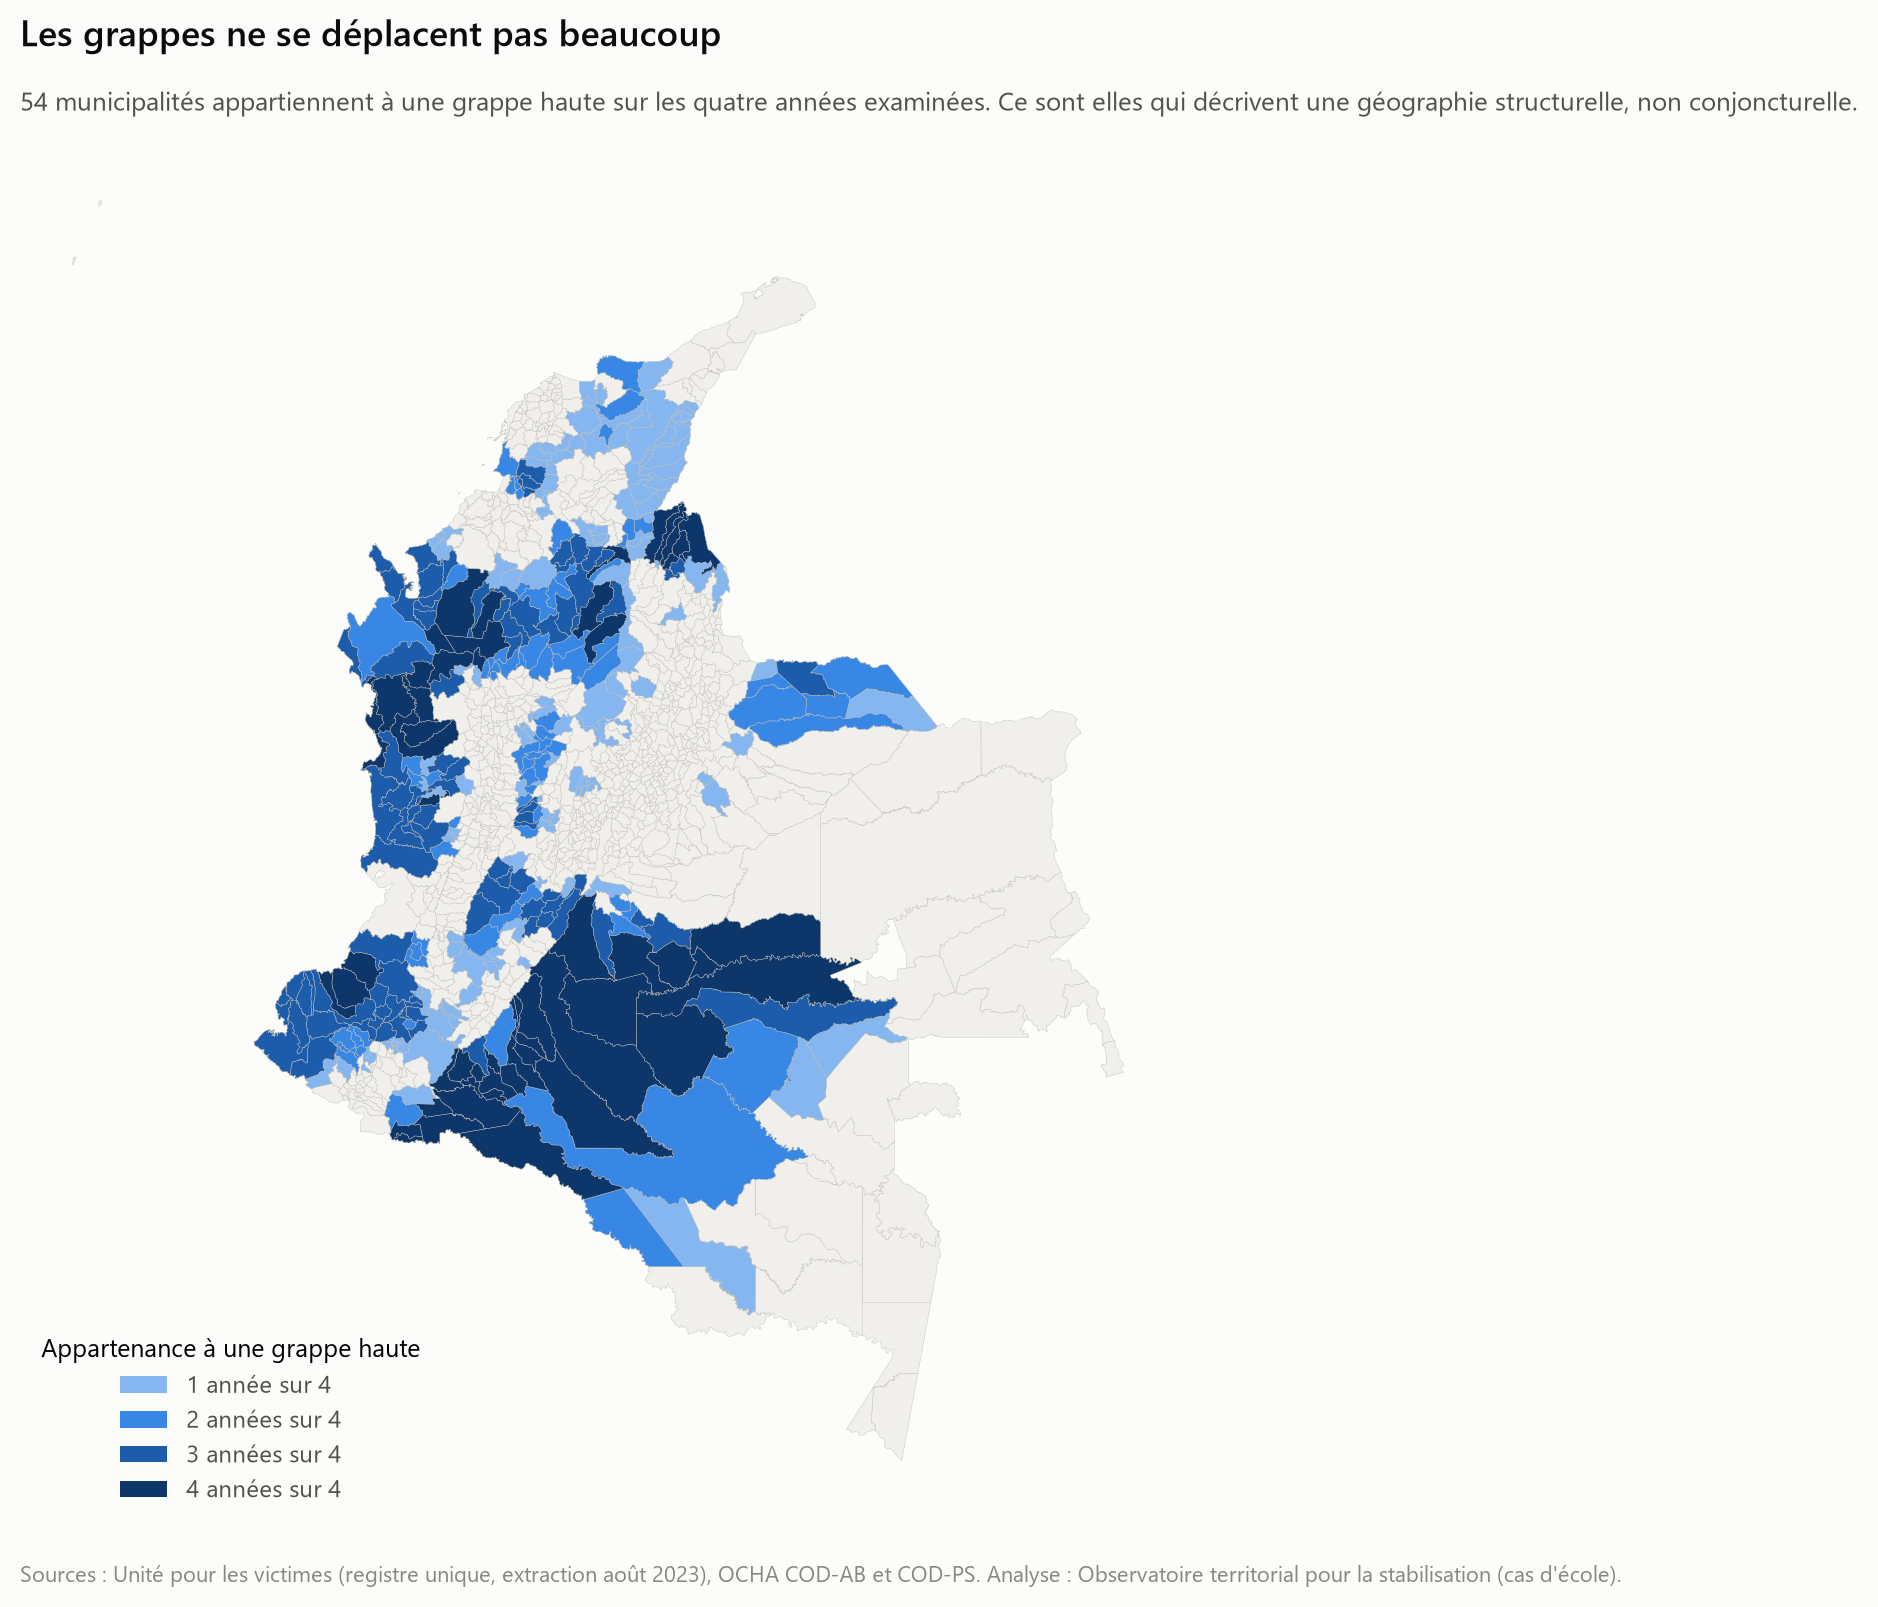

In [8]:
display(Image(filename=str(FIGURES / "fig05_grappes_persistantes.png")))

## 4. Ce que laissent les effets fixes

Si les violences locales suffisaient à expliquer la géographie du déplacement,
les résidus du modèle à effets fixes se répartiraient au hasard sur le
territoire. Le Moran des résidus reste positif et significatif.

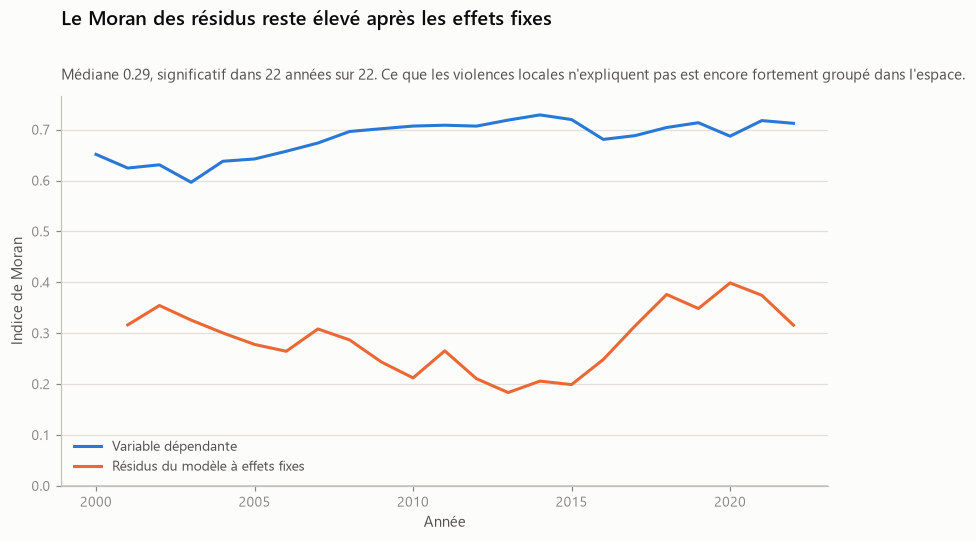

In [9]:
residus = pd.read_csv(TABLEAUX / "03_moran_residus.csv")
brut = pd.read_csv(TABLEAUX / "02_moran_global.csv")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.grid(axis="y", zorder=0)
ax.axhline(0, color=style.LIGNE_BASE, lw=1, zorder=1)
ax.plot(brut["annee"], brut["moran_I"], color=style.SERIE_1, lw=2,
        label="Variable dépendante", zorder=3)
ax.plot(residus["annee"], residus["moran_residus"], color=style.SERIE_2, lw=2,
        label="Résidus du modèle à effets fixes", zorder=3)
ax.set_ylabel("Indice de Moran")
ax.set_xlabel("Année")
ax.set_ylim(0, None)
ax.legend(labelcolor=style.ENCRE_SECONDAIRE)
style.titrer(
    ax,
    "Le Moran des résidus reste élevé après les effets fixes",
    f"Médiane {residus['moran_residus'].median():.2f}, significatif dans "
    f"{int(residus['significatif'].sum())} années sur {len(residus)}. Ce que les violences "
    "locales n'expliquent pas est encore fortement groupé dans l'espace.",
)
plt.show()

In [10]:
modeles = pd.read_csv(TABLEAUX / "03_comparaison_modeles.csv")
modeles.pivot(index="variable", columns="modele", values="coefficient").round(3)

modele,M1 effets fixes,M2 décalage spatial,M3 erreur spatiale
variable,,,
"Combats et engins explosifs, décalés d'un an",0.105,0.057,0.077
"Menaces, décalées d'un an",0.510,0.335,0.334
"Violence létale, décalée d'un an",0.447,0.274,0.277


In [11]:
pd.read_csv(TABLEAUX / "03_ajustement_modeles.csv").style.format({
    "log_vraisemblance": "{:,.0f}", "AIC": "{:,.0f}", "parametre_spatial": "{:.3f}",
})

,modele,log_vraisemblance,AIC,parametre_spatial
0,M2 décalage spatial,"-146,853","293,713",0.549
1,M3 erreur spatiale,"-147,338","294,681",0.586


Avec le terme spatial, les coefficients perdent près de 40 %. Le modèle sans ce
terme attribuait donc aux violences locales une part de ce qui relève de la
dépendance entre municipalités voisines.

## 5. Effets directs et indirects

In [12]:
effets = pd.read_csv(TABLEAUX / "03_effets_directs_indirects.csv")
effets.style.format({
    "effet_direct": "{:.3f}", "effet_indirect": "{:.3f}",
    "effet_total": "{:.3f}", "part_deversee": "{:.0%}",
})

,variable,effet_direct,effet_indirect,effet_total,part_deversee
0,"Violence létale, décalée d'un an",0.293,0.315,0.608,52%
1,"Menaces, décalées d'un an",0.358,0.386,0.744,52%
2,"Combats et engins explosifs, décalés d'un an",0.060,0.065,0.125,52%


La part déversée est la même pour les trois variables, par construction. Dans un
modèle à décalage spatial, le rapport de l'effet indirect à l'effet total ne
dépend que du paramètre spatial et de la matrice de voisinage, jamais du
coefficient de la variable. Le paramètre spatial décrit la géographie de la
diffusion, les coefficients en décrivent l'intensité.

Pour l'allocation des ressources, un financement ciblé sur une municipalité
isolée ne touche qu'environ la moitié de l'effet d'un choc.

## 6. Robustesse au choix du voisinage

Le résultat d'un modèle spatial dépend davantage de la matrice de voisinage
retenue que de la méthode d'estimation. Les deux définitions utilisées ici, k
plus proches voisins et contiguïté de type reine, sont donc comparées année par
année.

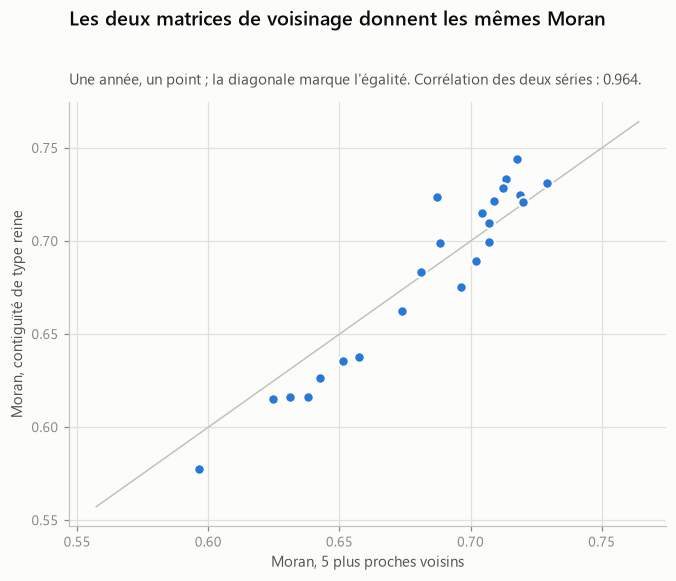

In [13]:
comparaison = pd.read_csv(TABLEAUX / "02_moran_comparaison_matrices.csv")

fig, ax = plt.subplots(figsize=(7, 5))
ax.grid(zorder=0)
lim = [comparaison[["moran_I_knn", "moran_I_reine"]].min().min() - 0.02,
       comparaison[["moran_I_knn", "moran_I_reine"]].max().max() + 0.02]
ax.plot(lim, lim, color=style.LIGNE_BASE, lw=1, zorder=2)
ax.scatter(comparaison["moran_I_knn"], comparaison["moran_I_reine"], s=48,
           color=style.SERIE_1, zorder=3, edgecolor=style.SURFACE, linewidths=1.4)
ax.set_xlabel(f"Moran, {K_VOISINS} plus proches voisins")
ax.set_ylabel("Moran, contiguïté de type reine")
style.titrer(
    ax,
    "Les deux matrices de voisinage donnent les mêmes Moran",
    f"Une année, un point ; la diagonale marque l'égalité. Corrélation des deux séries : "
    f"{comparaison['moran_I_knn'].corr(comparaison['moran_I_reine']):.3f}.",
)
plt.show()

## Limite

Rien ici n'identifie un effet causal. Les faits de violence et le déplacement
sont enregistrés par la même administration, à partir des mêmes déclarations, et
décaler d'un an ne suffit pas à rendre les régresseurs exogènes. Le modèle décrit
une structure de dépendance spatiale ; il ne dit pas par quel mécanisme le
déplacement se propage.

Les autres limites (couverture du registre, dénominateur de population, coca)
sont détaillées dans le README et dans `data/README_data.md`.